# Latent GP Classification — the Three Patterns

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/latent_gp_classification.ipynb)

For non-conjugate likelihoods (Bernoulli, Poisson, StudentT, …) the GP latent function cannot be marginalized analytically — we need `gp_sample` inside the NumPyro model. This notebook walks the three pyrox patterns through a 2D binary-classification problem.

**What you'll learn:**

1. Use `gp_sample` to register the latent GP function as a sample site under an arbitrary observation likelihood.
2. Compose it with a `Bernoulli(logits=f)` observation model.
3. Fit kernel hyperparameters with SVI across all three patterns.

## Background

### Joint model

For a non-conjugate likelihood $p(y \mid f)$, the hierarchical model is

$$\theta \sim p(\theta),
\quad f \mid X, \theta \sim \mathcal{N}\!\bigl(0, K_{XX}(\theta)\bigr), \quad y_i \mid f_i \sim \mathrm{Bernoulli}\!\bigl(\sigma(f_i)\bigr),$$

where $\sigma(z) = 1 / (1 + e^{-z})$ is the logistic link. The joint factorizes as

$$p(\theta, f, y \mid X)
= p(\theta)\, p(f \mid X, \theta)\, \prod_{i=1}^{N} p(y_i \mid f_i).$$

Because the likelihood is not Gaussian, the marginal $p(y \mid X, \theta) = \int p(y \mid f)\, p(f \mid X, \theta)\, df$ has no closed form — we can't collapse $f$ out the way we did for regression.

### Variational inference + the whitening trick

We approximate $p(\theta, f \mid X, y)$ by a factorized variational distribution and maximize the evidence lower bound

$$\mathcal{L}(\phi) =
\mathbb{E}_{q_\phi}\!\bigl[\log p(y \mid f)\bigr]
- \mathrm{KL}\!\bigl(q_\phi(\theta, f) \,\|\, p(\theta, f \mid X)\bigr).$$

A naive parameterization places $q_\phi(f)$ directly over the latent values at the training inputs. Under NumPyro's `AutoNormal` this becomes a *mean-field* Gaussian — independent across the $N$ training latents. That is a terrible approximation here, because the prior $p(f \mid X, \theta) = \mathcal{N}(0, K_{XX})$ has strong off-diagonal correlations and the optimum of the ELBO ends up dominated by that KL, not by the data fit. In practice the posterior over $f$ barely moves and the predictive decision boundary is essentially noise.

The standard fix is the **whitening reparameterization** (Murray & Adams, 2010; Hensman et al., 2015). Cholesky-factor the prior covariance once,

$$K_{XX}(\theta) + \epsilon I = L L^\top, \qquad u \sim \mathcal{N}(0, I_N), \qquad f = L u,$$

so the latent enters the likelihood through a *deterministic* transformation of an i.i.d. unit-Gaussian site. Now mean-field $q_\phi(u)$ is well-conditioned — there are no a-priori correlations between the $u_i$ to begin with — and the GP correlations come back into $f$ for free through $L$. Empirically this is the difference between a chaotic boundary and one that tracks the data.

### `gp_sample` modes — when to reach for which

pyrox exposes `gp_sample("f", prior, *, whitened, guide)` as the NumPyro-aware registration for the latent function. The three modes are mutually exclusive:

* **default** (`whitened=False`, `guide=None`) — registers a single $\mathcal{N}(\mu(X), K_{XX} + \epsilon I)$ sample site via `gaussx.MultivariateNormal`. The right call for **MCMC** (NUTS samples directly in the original $f$-space and handles the prior covariance correctly) and for **conjugate workflows** where you marginalize $f$ out via `gp_factor`.
* **whitened** (`whitened=True`) — registers an $N$-dimensional unit-Gaussian site $u \sim \mathcal{N}(0, I)$ and returns the deterministic $f = \mu(X) + L u$ shown above. The right call for **SVI on non-conjugate likelihoods** with NumPyro auto-guides such as `AutoNormal`. This is what every pattern in this notebook uses.
* **guide** (`guide=...`) — delegates to a concrete sparse variational guide (`FullRankGuide`, `MeanFieldGuide`, or `WhitenedGuide` over inducing values), which is the right call for the **sparse SVGP workflow** when $N$ is too large for an $N$-dimensional latent.

### Posterior predictive

For a test input $x_*$ the posterior predictive is

$$p(y_* = 1 \mid x_*, \mathcal{D})
= \int \sigma(f_*)\, p(f_* \mid x_*, \mathcal{D})\, df_*,$$

which we estimate by Monte Carlo + the logistic-Gaussian approximation further below.

### The three patterns

| Pattern | Kernel hyperparameters live in | When to reach for it |
|---|---|---|
| **A** | Pure `eqx.Module` + `numpyro.sample` + `eqx.tree_at` | Lightweight; no base class required. |
| **B** | Custom `PyroxModule` kernel that calls `pyrox_sample` in `__call__` | Self-contained probabilistic kernel. |
| **C** | `Parameterized` kernel (shipped `RBF`, `Matern`, …) with `set_prior` | Full registry, constraints, autoguides, modes. |

Only the *kernel construction* differs across patterns — the whitening boilerplate and the Bernoulli likelihood are shared via a small helper.


## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jaxtyping import Array, Float
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam

from pyrox._core import PyroxModule, pyrox_method
from pyrox.gp import RBF, GPPrior, Kernel, gp_sample
from pyrox.gp._src.kernels import rbf_kernel


jax.config.update("jax_enable_x64", True)

Reproducibility readout.

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,gaussx,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.12.0

jax       : 0.8.3
equinox   : 0.13.7
numpyro   : 0.20.1
gaussx    : 0.0.10
pyrox     : 0.0.6
matplotlib: 3.10.8

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## Toy 2D binary dataset

Two interleaved half-moons — the boundary between them is the function the latent GP has to learn.

Training points: 40
Grid points:     1600


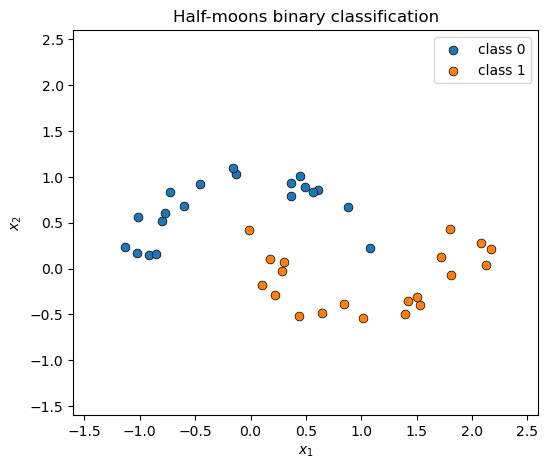

In [4]:
key = jr.PRNGKey(0)


def make_half_moons(key, n_per_class=30):
    k1, k2, k3, k4 = jr.split(key, 4)
    theta0 = jnp.pi * jr.uniform(k1, (n_per_class,))
    x0 = jnp.stack([jnp.cos(theta0), jnp.sin(theta0)], axis=-1)
    x0 = x0 + 0.1 * jr.normal(k2, x0.shape)
    theta1 = jnp.pi + jnp.pi * jr.uniform(k3, (n_per_class,))
    x1 = jnp.stack([1.0 + jnp.cos(theta1), 0.5 + jnp.sin(theta1)], axis=-1)
    x1 = x1 + 0.1 * jr.normal(k4, x1.shape)
    X = jnp.concatenate([x0, x1], axis=0)
    y = jnp.concatenate([jnp.zeros(n_per_class), jnp.ones(n_per_class)], axis=0).astype(
        jnp.int32
    )
    return X, y


X_train, y_train = make_half_moons(key, n_per_class=20)

grid_lo, grid_hi = -1.6, 2.6
grid_steps = 40
xx, yy = jnp.meshgrid(
    jnp.linspace(grid_lo, grid_hi, grid_steps),
    jnp.linspace(grid_lo, grid_hi, grid_steps),
)
X_grid = jnp.stack([xx.ravel(), yy.ravel()], axis=-1)

print(f"Training points: {X_train.shape[0]}")
print(f"Grid points:     {X_grid.shape[0]}")


def scatter_data(ax):
    mask0 = y_train == 0
    ax.scatter(
        X_train[mask0, 0],
        X_train[mask0, 1],
        s=40,
        c="C0",
        edgecolors="k",
        linewidths=0.5,
        label="class 0",
        zorder=5,
    )
    ax.scatter(
        X_train[~mask0, 0],
        X_train[~mask0, 1],
        s=40,
        c="C1",
        edgecolors="k",
        linewidths=0.5,
        label="class 1",
        zorder=5,
    )
    ax.set_xlim(grid_lo, grid_hi)
    ax.set_ylim(grid_lo, grid_hi)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")


fig, ax = plt.subplots(figsize=(6, 5))
scatter_data(ax)
ax.set_title("Half-moons binary classification")
ax.legend()
plt.show()

## The common model skeleton

All three patterns share the same whitened latent + Bernoulli likelihood — the only thing that changes is how `kernel` is built (which is the whole point of comparing the patterns):

```text
prior = GPPrior(kernel, X, jitter=1e-4)   # kernel built per-pattern
f     = gp_sample("f", prior, whitened=True)
        # samples u ~ N(0, I_N) and returns the deterministic
        # f = mu(X) + L u with L = chol(K + jitter*I)
obs   ~ Bernoulli(logits=f)
```

`gp_sample(..., whitened=True)` is the model-layer entry point that registers the unit-Gaussian site as `"f_u"` and the unwhitened function value as the deterministic `"f"`. Each pattern's model function then reads as "build the kernel, then run the standard whitened-classification pipeline."

## Pattern A — pure Equinox + `eqx.tree_at`

In [5]:
class RBFLite(Kernel):
    """Minimal Equinox-native RBF kernel."""

    variance: Float[Array, ""]
    lengthscale: Float[Array, ""]

    def __call__(
        self, X1: Float[Array, "N1 D"], X2: Float[Array, "N2 D"]
    ) -> Float[Array, "N1 N2"]:
        return rbf_kernel(X1, X2, self.variance, self.lengthscale)


def model_pattern_a(X, y):
    variance = numpyro.sample("variance", dist.LogNormal(0.0, 1.0))
    lengthscale = numpyro.sample("lengthscale", dist.LogNormal(0.0, 1.0))
    kernel = RBFLite(variance=jnp.array(1.0), lengthscale=jnp.array(1.0))
    kernel = eqx.tree_at(
        lambda k: (k.variance, k.lengthscale),
        kernel,
        (variance, lengthscale),
    )
    prior = GPPrior(kernel=kernel, X=X, jitter=1e-4)
    f = gp_sample("f", prior, whitened=True)
    numpyro.sample("obs", dist.Bernoulli(logits=f), obs=y)

## Pattern B — `PyroxModule` kernel with `pyrox_sample`

In [6]:
class RBFPyrox(Kernel, PyroxModule):
    """PyroxModule kernel with inline prior registration."""

    pyrox_name: str = "RBFPyrox"

    @pyrox_method
    def __call__(
        self, X1: Float[Array, "N1 D"], X2: Float[Array, "N2 D"]
    ) -> Float[Array, "N1 N2"]:
        variance = self.pyrox_sample("variance", dist.LogNormal(0.0, 1.0))
        lengthscale = self.pyrox_sample("lengthscale", dist.LogNormal(0.0, 1.0))
        return rbf_kernel(X1, X2, variance, lengthscale)


def model_pattern_b(X, y):
    kernel = RBFPyrox()
    prior = GPPrior(kernel=kernel, X=X, jitter=1e-4)
    f = gp_sample("f", prior, whitened=True)
    numpyro.sample("obs", dist.Bernoulli(logits=f), obs=y)

## Pattern C — `Parameterized` kernel with `set_prior`

In [7]:
def model_pattern_c(X, y):
    kernel = RBF()
    kernel.set_prior("variance", dist.LogNormal(0.0, 1.0))
    kernel.set_prior("lengthscale", dist.LogNormal(0.0, 1.0))
    prior = GPPrior(kernel=kernel, X=X, jitter=1e-4)
    f = gp_sample("f", prior, whitened=True)
    numpyro.sample("obs", dist.Bernoulli(logits=f), obs=y)

## Fit all three with the same SVI loop

In [8]:
def fit(model_fn, seed, n_steps=400):
    guide = AutoNormal(model_fn)
    svi = SVI(model_fn, guide, Adam(2e-2), Trace_ELBO())
    state = svi.init(jr.PRNGKey(seed), X_train, y_train)
    losses = []
    for _ in range(n_steps):
        state, loss = svi.update(state, X_train, y_train)
        losses.append(float(loss))
    return state, svi, guide, losses


state_a, svi_a, guide_a, losses_a = fit(model_pattern_a, 1)
state_b, svi_b, guide_b, losses_b = fit(model_pattern_b, 2)
state_c, svi_c, guide_c, losses_c = fit(model_pattern_c, 3)


def posterior_hyperparams(svi, state, variance_site, lengthscale_site):
    params = svi.get_params(state)
    variance = float(jnp.exp(params[f"{variance_site}_auto_loc"]))
    lengthscale = float(jnp.exp(params[f"{lengthscale_site}_auto_loc"]))
    return variance, lengthscale


v_a, ls_a = posterior_hyperparams(svi_a, state_a, "variance", "lengthscale")
v_b, ls_b = posterior_hyperparams(
    svi_b, state_b, "RBFPyrox.variance", "RBFPyrox.lengthscale"
)
v_c, ls_c = posterior_hyperparams(svi_c, state_c, "RBF.variance", "RBF.lengthscale")

print(f"{'pattern':<10} {'variance':>10} {'lengthscale':>12}")
print("-" * 36)
print(f"{'A':<10} {v_a:>10.3f} {ls_a:>12.3f}")
print(f"{'B':<10} {v_b:>10.3f} {ls_b:>12.3f}")
print(f"{'C':<10} {v_c:>10.3f} {ls_c:>12.3f}")

pattern      variance  lengthscale
------------------------------------
A               4.707        0.704
B               4.070        0.699
C               4.326        0.767


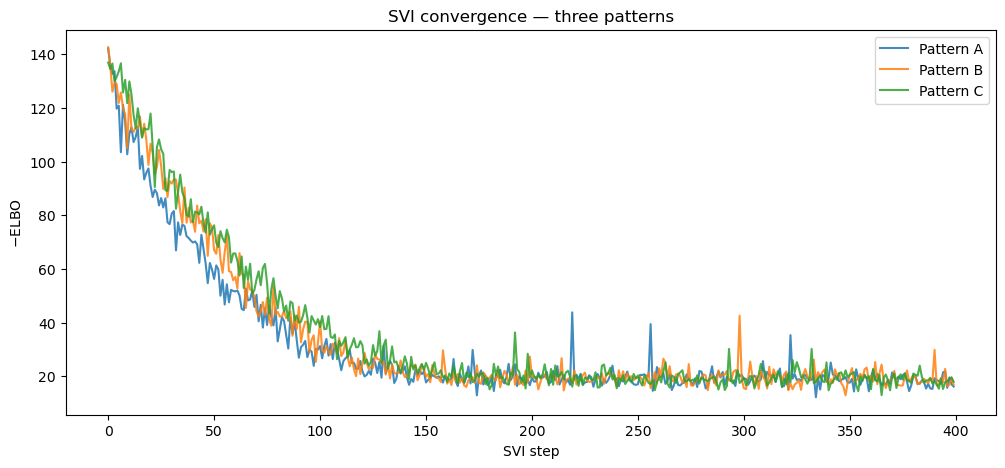

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(losses_a, "C0-", label="Pattern A", alpha=0.85)
ax.plot(losses_b, "C1-", label="Pattern B", alpha=0.85)
ax.plot(losses_c, "C2-", label="Pattern C", alpha=0.85)
ax.set_xlabel("SVI step")
ax.set_ylabel(r"$-$ELBO")
ax.set_title("SVI convergence — three patterns")
ax.legend()
plt.show()

## Decision boundaries — MC-averaged posterior predictive

We want the Bayesian posterior predictive

$$p(y_* = 1 \mid x_*, \mathcal{D})
= \iint \sigma(f_*)\, p(f_* \mid x_*, f, \theta)\, q(\theta, u)\, df_*\, du\, d\theta,$$

where $q(\theta, u)$ is the SVI guide posterior over the kernel hyperparameters and the *whitened* latent, and $p(f_* \mid x_*, f, \theta)$ is the standard noise-free GP conditional

$$p(f_* \mid x_*, f, \theta) = \mathcal{N}\!\bigl(\mu_*, \sigma_*^2\bigr),
\qquad \mu_* = k_*^\top\bigl(K_{XX} + \epsilon I\bigr)^{-1} f, \qquad \sigma_*^2 = k_{**} - k_*^\top\bigl(K_{XX} + \epsilon I\bigr)^{-1} k_*,$$

with $k_* = K(x_*, X)$ and $k_{**} = K(x_*, x_*)$. $\epsilon$ is the same jitter used inside `latent_f`.

We estimate the outer integral by Monte Carlo and the inner integral by the logistic-Gaussian approximation

$$\int \sigma(f_*)\, \mathcal{N}(f_* \mid \mu_*, \sigma_*^2)\, df_*
\;\approx\; \sigma\bigl(\kappa(\sigma_*^2)\, \mu_*\bigr), \qquad \kappa(v) = \bigl(1 + \pi v / 8\bigr)^{-1/2},$$

which is exact for the probit link and within a percent for the logistic link that we actually use (MacKay, 1992).

Putting it together — for each MC sample $s$:

1. Draw $(\theta_s, u_s) \sim q_\phi$ from the SVI guide.
2. Reconstruct the training-time latent $f_s = L(\theta_s)\, u_s$ with the matching Cholesky.
3. Build the GP prior at $\theta_s$ and condition on $f_s$ to get $(\mu_{*, s}, \sigma_{*, s}^2)$ at the grid points.
4. Apply the logistic-Gaussian approximation to get per-sample class probabilities.

Average:

$$p(y_* = 1 \mid x_*, \mathcal{D}) \;\approx\;
\tfrac{1}{S}\sum_{s=1}^{S} \sigma\!\bigl(\kappa(\sigma_{*, s}^2)\, \mu_{*, s}\bigr).$$

This uses the actual fitted Bernoulli model — no Gaussian-likelihood stand-in anywhere.


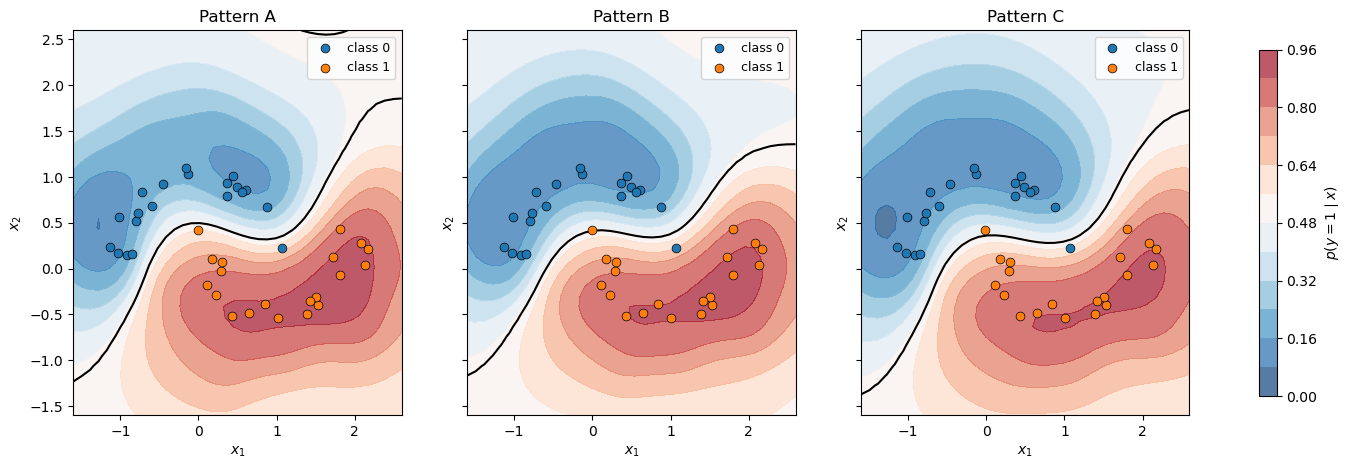

In [10]:
N_MC = 16


def predict_prob(guide, svi_obj, state, variance_site, lengthscale_site):
    """MC-averaged posterior predictive for the Bernoulli GP.

    Each guide sample yields ``(theta_s, u_s)`` over the kernel
    hyperparameters and the whitened latent. We reconstruct the
    training-time latent ``f_s = L(theta_s) @ u_s``, condition the GP
    on ``f_s`` as noise-free observations, and apply the
    logistic-Gaussian approximation to get class probabilities at the
    grid points before averaging across samples.
    """
    params = svi_obj.get_params(state)
    posterior = guide.sample_posterior(jr.PRNGKey(42), params, sample_shape=(N_MC,))
    variances = posterior[variance_site]
    lengthscales = posterior[lengthscale_site]
    u_samples = posterior["f_u"]  # (N_MC, N_train)

    probs = []
    for v, ls, u in zip(variances, lengthscales, u_samples):
        kernel = RBF(init_variance=float(v), init_lengthscale=float(ls))
        prior = GPPrior(kernel=kernel, X=X_train, jitter=1e-4)
        L = jnp.linalg.cholesky(prior._prior_operator().as_matrix())
        f_train = L @ u
        # Condition on the reconstructed latent as noise-free observations.
        cond = prior.condition(f_train, jnp.array(1e-4))
        mean, var = cond.predict(X_grid)
        kappa = 1.0 / jnp.sqrt(1.0 + jnp.pi * jnp.clip(var, min=0.0) / 8.0)
        probs.append(jax.nn.sigmoid(kappa * mean))
    return jnp.mean(jnp.stack(probs), axis=0).reshape(grid_steps, grid_steps)


prob_a = predict_prob(guide_a, svi_a, state_a, "variance", "lengthscale")
prob_b = predict_prob(
    guide_b, svi_b, state_b, "RBFPyrox.variance", "RBFPyrox.lengthscale"
)
prob_c = predict_prob(guide_c, svi_c, state_c, "RBF.variance", "RBF.lengthscale")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, prob, title in zip(
    axes, [prob_a, prob_b, prob_c], ["Pattern A", "Pattern B", "Pattern C"]
):
    cf = ax.contourf(
        xx, yy, prob, levels=10, cmap="RdBu_r", alpha=0.7, vmin=0.0, vmax=1.0
    )
    ax.contour(xx, yy, prob, levels=[0.5], colors="k", linewidths=1.5)
    scatter_data(ax)
    ax.set_title(title)
    ax.legend(fontsize=9)
fig.colorbar(cf, ax=axes, shrink=0.9, label=r"$p(y=1 \mid x)$")
plt.show()

## When to use which

The non-conjugate story is exactly the conjugate story with `gp_factor` swapped for `gp_sample` + an explicit likelihood. The pattern choice is still purely ergonomic:

- **Pattern A** — lightest; sample hyperparameters at the model level and splice into a pure Equinox kernel. Good for one-off Bayesian extensions.
- **Pattern B** — custom `PyroxModule` kernel that owns its priors. Good when the kernel is a reusable probabilistic building block.
- **Pattern C** — full registry via `Parameterized`. Use the shipped `RBF`, `Matern`, etc., and attach priors / autoguides / modes declaratively.

Switch the likelihood, change nothing else — `Bernoulli(logits=f)` becomes `Poisson(rate=jnp.exp(f))` for counts, `StudentT(...)` for robust regression, and so on.